In [1]:
import time
import requests

In [23]:
headers = {"User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) ")}

In [28]:
url = "https://www.parfumo.com/Perfumes/Trends"
html = requests.get(url, headers=headers).text

print(html[:500])


<!DOCTYPE html>

<html lang="en">

	<head>
		
				<meta name="google-site-verification" content="zxJUhAYvkrWKUiYnD8mz27WHweO2nORrD06ONz9gECs">		<meta name="p:domain_verify" content="79c9b1baaf16bed67e4ba17dde6eee91"/>
		<meta name="fo-verify" content="48fe1994-cec3-46d7-8168-e8f1a7f889ef">
		<meta charset="utf-8">
		<link rel="preconnect" href="https://media.parfumo.com" crossorigin>
				<meta name="viewport" content="width=device-width, initial-scale=1.0, viewport-fit=cover">
				<meta name="r


In [3]:
from bs4 import BeautifulSoup

In [30]:
soup = BeautifulSoup(html, "html.parser")
print(soup.title.text)

The most Users own - Discover Perfumes at Parfumo


In [31]:
perfumes = soup.find_all("div", class_="col")
print(len(perfumes))

54


In [32]:
first = perfumes[0]
print(first.text)






Libre  Eau de Parfum




In [33]:
name = first.find("div", class_="name")
print(name.text)


Libre  Eau de Parfum



In [34]:
link = first.find("a")
print(link.get("href"))

https://www.parfumo.com/Perfumes/Yves_Saint_Laurent/libre-eau-de-parfum


In [43]:
data = []

for perfume in perfumes:
    new_name = perfume.find("div", class_="name")
    new_link = perfume.find("a")

    if new_name is not None and new_link is not None:
        name = new_name.text.strip()
        link = new_link.get("href").strip()
        data.append({"name": name, "link": link})

print(data)

[{'name': 'Libre  Eau de Parfum', 'link': 'https://www.parfumo.com/Perfumes/Yves_Saint_Laurent/libre-eau-de-parfum'}, {'name': 'For Her Pure Musc  Eau de Parfum', 'link': 'https://www.parfumo.com/Perfumes/Narciso_Rodriguez/for-her-pure-musc-eau-de-parfum'}, {'name': 'Libre  Eau de Parfum Intense', 'link': 'https://www.parfumo.com/Perfumes/Yves_Saint_Laurent/libre-eau-de-parfum-intense'}, {'name': 'Light Blue  Eau de Toilette', 'link': 'https://www.parfumo.com/Perfumes/Dolce_Gabbana/light-blue-eau-de-toilette'}, {'name': 'Cloud  Eau de Parfum', 'link': 'https://www.parfumo.com/Perfumes/Ariana_Grande/cloud-eau-de-parfum'}, {'name': 'Delina  Eau de Parfum', 'link': 'https://www.parfumo.com/Perfumes/Parfums_de_Marly/Delina'}, {'name': 'Mon Guerlain  Eau de Parfum', 'link': 'https://www.parfumo.com/Perfumes/Guerlain/Mon_Guerlain'}, {'name': "La Vie est Belle (L'Eau de Parfum)", 'link': 'https://www.parfumo.com/Perfumes/Lancome/la-vie-est-belle-l-eau-de-parfum'}, {'name': 'Eclaire', 'link': 

In [2]:
import pandas as pd

In [53]:
df = pd.DataFrame(data)
print(df.head())

                               name  \
0              Libre  Eau de Parfum   
1  For Her Pure Musc  Eau de Parfum   
2      Libre  Eau de Parfum Intense   
3       Light Blue  Eau de Toilette   
4              Cloud  Eau de Parfum   

                                                link  
0  https://www.parfumo.com/Perfumes/Yves_Saint_La...  
1  https://www.parfumo.com/Perfumes/Narciso_Rodri...  
2  https://www.parfumo.com/Perfumes/Yves_Saint_La...  
3  https://www.parfumo.com/Perfumes/Dolce_Gabbana...  
4  https://www.parfumo.com/Perfumes/Ariana_Grande...  


In [54]:
print(df.shape)

(54, 2)


In [71]:
top_data = []
types = ["Men", "Women","Unisex"]

for type in types:
    for page in range(1,6):
        url = f"https://www.parfumo.com/Perfumes/Tops/{type}?current_page={page}"
        html = requests.get(url, headers=headers).text
        soup = BeautifulSoup(html, "html.parser")

        perfumes = soup.find_all("div", class_="col")

        for perfume in perfumes:
            new_name = perfume.find("div", class_="name")
            new_link = perfume.find("a")
            new_av_scent = perfume.find("div", class_="av av_scent")

            if new_name is not None and new_link is not None and new_av_scent is not None:
                full_name = new_name.text.strip()
                parts = full_name.split("\n - ")
                name = parts[0]
                brand = parts[1] if len(parts) > 1 else None

                link = new_link.get("href").strip()

                av_scent = new_av_scent.text.strip()
                rating_parts = av_scent.split()
                rating = float(rating_parts[0])
                votes = int(rating_parts[1])

                top_data.append({"name": name, "brand": brand, "link": link, "rating": rating, "votes": votes, "genre": type})
top_data[:10]

[{'name': 'Imagination',
  'brand': 'Louis Vuitton',
  'link': 'https://www.parfumo.com/Perfumes/Louis_Vuitton/imagination',
  'rating': 8.9,
  'votes': 8802,
  'genre': 'Men'},
 {'name': 'Layton',
  'brand': 'Parfums de Marly',
  'link': 'https://www.parfumo.com/Perfumes/Parfums_de_Marly/Layton',
  'rating': 8.6,
  'votes': 8626,
  'genre': 'Men'},
 {'name': 'Dior Homme Intense (2011)',
  'brand': 'Dior',
  'link': 'https://www.parfumo.com/Perfumes/Dior/Dior_Homme_Intense_2011',
  'rating': 8.5,
  'votes': 8411,
  'genre': 'Men'},
 {'name': 'Aventus',
  'brand': 'Creed',
  'link': 'https://www.parfumo.com/Perfumes/Creed/aventus',
  'rating': 8.4,
  'votes': 8216,
  'genre': 'Men'},
 {'name': 'Reflection Man',
  'brand': 'Amouage',
  'link': 'https://www.parfumo.com/Perfumes/Amouage/Reflection_Man',
  'rating': 8.6,
  'votes': 6191,
  'genre': 'Men'},
 {'name': "L'Homme",
  'brand': 'Prada',
  'link': 'https://www.parfumo.com/Perfumes/Prada/L_Homme',
  'rating': 8.4,
  'votes': 7483,
 

In [72]:
df = pd.DataFrame(top_data)

In [73]:
df.to_csv("perfumes.csv", index=False)

In [74]:
print(df.shape)

(1500, 6)


In [75]:
df = df.drop_duplicates(subset=["name", "brand"])

In [76]:
print(df.shape)

(1500, 6)


In [89]:
html = requests.get("https://www.parfumo.com/Perfumes/Guerlain/Mon_Guerlain", headers=headers).text
soup = BeautifulSoup(html, "html.parser")

notes_section = soup.find("div", class_="notes_list")

print(notes_section.text[:1000])




 Top Notes					
Juniper berry Bergamot Cedar leaf Grapefruit Lemon Petitgrain Nested Nutmeg



 Heart Notes					
Fir balsam Lavender Laurel Oblique Oakmoss



 Base Notes					
Cedarwood Moss Vetiver Leather Musk Patchouli Amber 




In [4]:
from selenium import webdriver
from selenium.webdriver.edge.service import Service
from webdriver_manager.microsoft import EdgeChromiumDriverManager

In [6]:
driver = webdriver.Chrome()

In [8]:
driver.get("https://www.parfumo.com/Perfumes/Guerlain/Mon_Guerlain")
time.sleep(5)

In [103]:
html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

In [104]:
notes_section = soup.find("div", class_="notes_list")

imgs = notes_section.find_all("img")

notes = [img.get("alt") for img in imgs if img.get("alt")]

print(notes)

['Cedarwood', 'Lemon', 'Oakmoss', 'Petitgrain', 'Sandalwood', 'Tonka bean']


In [ ]:
for link in df["link"]:
    driver.get(link)
    time.sleep(5)

    html = driver.page_source
    soup = BeautifulSoup(html, "html.parser")

    notes_section = soup.find("div", class_="notes_list")
    imgs = notes_section.find_all("img")
    notes = [img.get("alt") for img in imgs if img.get("alt")]




In [5]:
df = pd.read_csv("../data/perfumes.csv")

In [10]:
all_notes_data = []

for _, row in df.iterrows():

    driver.get(row["link"])
    time.sleep(1)

    html = driver.page_source
    soup = BeautifulSoup(html, "html.parser")

    notes_section = soup.find("div", class_="notes_list")

    if notes_section is None:
        continue

    top_block = notes_section.find("div", class_="nb_t")
    middle_block = notes_section.find("div", class_="nb_m")
    base_block = notes_section.find("div", class_="nb_b")

    top_notes = []
    middle_notes = []
    base_notes = []

    if top_block:
        top_notes = [
            img.get("alt")
            for img in top_block.find_all("img")
            if img.get("alt")
        ]

    if middle_block:
        middle_notes = [
            img.get("alt")
            for img in middle_block.find_all("img")
            if img.get("alt")
        ]

    if base_block:
        base_notes = [
            img.get("alt")
            for img in base_block.find_all("img")
            if img.get("alt")
        ]

    all_notes_data.append({
        "name": row["name"],
        "brand": row["brand"],
        "genre": row["genre"],
        "rating": row["rating"],
        "votes": row["votes"],
        "link": row["link"],
        "top_notes": top_notes,
        "middle_notes": middle_notes,
        "base_notes": base_notes
    })

    if len(all_notes_data) % 50 == 0:
        pd.DataFrame(all_notes_data).to_csv("../data/perfume_dataset_backup.csv", index=False)

In [11]:
top_notes = [note for note in top_notes if note != "Top Notes"]

middle_notes = [
    note for note in middle_notes
    if note != "Heart Notes"
]

base_notes = [
    note for note in base_notes
    if note != "Base Notes"
]

In [12]:
df = pd.DataFrame(all_notes_data)
print(df.head())

                        name             brand genre  rating  votes  \
0                Imagination     Louis Vuitton   Men     8.9   8802   
1                     Layton  Parfums de Marly   Men     8.6   8626   
2  Dior Homme Intense (2011)              Dior   Men     8.5   8411   
3                    Aventus             Creed   Men     8.4   8216   
4             Reflection Man           Amouage   Men     8.6   6191   

                                                link  \
0  https://www.parfumo.com/Perfumes/Louis_Vuitton...   
1  https://www.parfumo.com/Perfumes/Parfums_de_Ma...   
2  https://www.parfumo.com/Perfumes/Dior/Dior_Hom...   
3     https://www.parfumo.com/Perfumes/Creed/aventus   
4  https://www.parfumo.com/Perfumes/Amouage/Refle...   

                                       top_notes  \
0                                             []   
1                          [Top Notes, Cinnamon]   
2                                             []   
3  [Top Notes, Mugwort, Card

In [13]:
df["top_notes"] = df["top_notes"].apply(lambda x: [note for note in x if note != "Top Notes"])
df["middle_notes"] = df["middle_notes"].apply(lambda x: [note for note in x if note != "Heart Notes"])
df["base_notes"] = df["base_notes"].apply(lambda x: [note for note in x if note != "Base Notes"])

In [14]:
print(df.head())

                        name             brand genre  rating  votes  \
0                Imagination     Louis Vuitton   Men     8.9   8802   
1                     Layton  Parfums de Marly   Men     8.6   8626   
2  Dior Homme Intense (2011)              Dior   Men     8.5   8411   
3                    Aventus             Creed   Men     8.4   8216   
4             Reflection Man           Amouage   Men     8.6   6191   

                                                link  \
0  https://www.parfumo.com/Perfumes/Louis_Vuitton...   
1  https://www.parfumo.com/Perfumes/Parfums_de_Ma...   
2  https://www.parfumo.com/Perfumes/Dior/Dior_Hom...   
3     https://www.parfumo.com/Perfumes/Creed/aventus   
4  https://www.parfumo.com/Perfumes/Amouage/Refle...   

                            top_notes  \
0                                  []   
1                          [Cinnamon]   
2                                  []   
3  [Mugwort, Cardamom, Davana, Lemon]   
4                              

In [15]:
for idx, row in df.iterrows():

    if row["top_notes"] == []:

        driver.get(row["link"])
        time.sleep(1)

        html = driver.page_source
        soup = BeautifulSoup(html, "html.parser")

        notes_section = soup.find("div", class_="notes_list")

        if notes_section is None:
            continue

        top_block = notes_section.find("div", class_="nb_t")
        middle_block = notes_section.find("div", class_="nb_m")
        base_block = notes_section.find("div", class_="nb_b")

        if top_block:
            df.at[idx, "top_notes"] = [
                span.text.strip()
                for span in top_block.find_all("span", class_="nowrap")
            ]

        if middle_block:
            df.at[idx, "middle_notes"] = [
                span.text.strip()
                for span in middle_block.find_all("span", class_="nowrap")
            ]

        if base_block:
            df.at[idx, "base_notes"] = [
                span.text.strip()
                for span in base_block.find_all("span", class_="nowrap")
            ]
        if len(all_notes_data) % 50 == 0:
            pd.DataFrame(all_notes_data).to_csv("../data/perfume_dataset_backup.csv", index=False)


In [16]:
print(df.head())

                        name             brand genre  rating  votes  \
0                Imagination     Louis Vuitton   Men     8.9   8802   
1                     Layton  Parfums de Marly   Men     8.6   8626   
2  Dior Homme Intense (2011)              Dior   Men     8.5   8411   
3                    Aventus             Creed   Men     8.4   8216   
4             Reflection Man           Amouage   Men     8.6   6191   

                                                link  \
0  https://www.parfumo.com/Perfumes/Louis_Vuitton...   
1  https://www.parfumo.com/Perfumes/Parfums_de_Ma...   
2  https://www.parfumo.com/Perfumes/Dior/Dior_Hom...   
3     https://www.parfumo.com/Perfumes/Creed/aventus   
4  https://www.parfumo.com/Perfumes/Amouage/Refle...   

                                           top_notes  \
0  [Bergamot, Elemi resin, Lemon, Pink pepper, Sa...   
1                                         [Cinnamon]   
2                                                 []   
3           

In [18]:
df = (df)[(df["top_notes"].str.len() > 0) | (df["middle_notes"].str.len() > 0) | (df["base_notes"].str.len() > 0)]

In [19]:
print(df.shape)

(1015, 9)


In [20]:
df["all_notes"] = (df["top_notes"] + df["middle_notes"] + df["base_notes"])

In [21]:
df["notes_text"] = df["all_notes"].apply(
    lambda x: " ".join(x).lower()
)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [29]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["notes_text"])

In [30]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14834 stored elements and shape (1015, 760)>
  Coords	Values
  (0, 87)	0.11074388646600589
  (0, 260)	0.2259290491345053
  (0, 582)	0.25667299924266374
  (0, 411)	0.15114502472291055
  (0, 553)	0.18867756669636163
  (0, 539)	0.15868260966276387
  (0, 602)	0.1971268990550924
  (0, 633)	0.2823316660543848
  (0, 160)	0.15083944055783047
  (0, 54)	0.29721049500071944
  (0, 149)	0.1797844204580066
  (0, 579)	0.24388737666205623
  (0, 697)	0.2931002159609133
  (0, 25)	0.11650543020530814
  (0, 157)	0.2362777379470066
  (0, 746)	0.1971268990550924
  (0, 223)	0.2733178159911174
  (0, 475)	0.08940108852022592
  (0, 533)	0.12275165447405798
  (0, 585)	0.2362777379470066
  (0, 705)	0.1626849832489685
  (0, 80)	0.16907632111403653
  (0, 379)	0.250829348329733
  (1, 746)	0.32029851870223175
  (1, 475)	0.14526194223444172
  :	:
  (1013, 323)	0.3119414489203566
  (1013, 455)	0.3194175896821668
  (1013, 507)	0.22066727422745497
  (1013, 546

In [32]:
similarity = cosine_similarity(X)
print(similarity)

[[1.         0.10060898 0.19020801 ... 0.         0.03535467 0.2024878 ]
 [0.10060898 1.         0.         ... 0.03004364 0.05729277 0.        ]
 [0.19020801 0.         1.         ... 0.08388041 0.14153762 0.09725664]
 ...
 [0.         0.03004364 0.08388041 ... 1.         0.11100652 0.01545508]
 [0.03535467 0.05729277 0.14153762 ... 0.11100652 1.         0.01545398]
 [0.2024878  0.         0.09725664 ... 0.01545508 0.01545398 1.        ]]


In [49]:
def recommend_perfumes(name, n=5):

    idx = df[df["name"] == name].index[0]
    target_genre = df.iloc[idx]["genre"]
    similarity_scores = similarity[idx]
    scored_perfumes = []

    for perfume_idx, similarity_score in enumerate(similarity_scores):

        if perfume_idx == idx:
            continue

        perfume = df.iloc[perfume_idx]

        if perfume["genre"] != target_genre:
            continue

        normalized_rating = perfume["rating"] / 10

        normalized_votes = min(perfume["votes"] / 10000, 1)

        final_score = (similarity_score * 0.7 + normalized_rating * 0.2 + normalized_votes * 0.1)

        scored_perfumes.append((perfume_idx, final_score, similarity_score))

    scored_perfumes = sorted(scored_perfumes, key=lambda x: x[1], reverse=True)

    recommendations = []

    for perfume_idx, final_score, similarity_score in scored_perfumes[:n]:
        perfume = df.iloc[perfume_idx]

        recommendations.append({
            "name": perfume["name"],
            "brand": perfume["brand"],
            "genre": perfume["genre"],
            "rating": perfume["rating"],
            "votes": perfume["votes"],
            "similarity": round(similarity_score, 3),
            "final_score": round(final_score, 3)
        })

    return pd.DataFrame(recommendations)

In [50]:
recomendation = recommend_perfumes("Layton")
print(recomendation)

                                             name               brand genre  \
0                                 Art of Arabia I       Lattafa Pride   Men   
1               Gentleman Givenchy  Eau de Parfum            Givenchy   Men   
2                                            1888          Casamorati   Men   
3  Rive Gauche pour Homme (2003)  Eau de Toilette  Yves Saint Laurent   Men   
4                       Héritage  Eau de Toilette            Guerlain   Men   

   rating  votes  similarity  final_score  
0     8.2    922       0.520        0.537  
1     8.0   1814       0.484        0.517  
2     8.2   1294       0.435        0.482  
3     8.2    294       0.352        0.413  
4     8.2    764       0.324        0.398  


In [51]:
from sklearn.cluster import KMeans

In [52]:
model = KMeans(n_clusters=10)

In [54]:
clusters = model.fit_predict(X)

In [55]:
df["cluster"] = clusters

In [56]:
from sklearn.decomposition import PCA

In [57]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X.toarray())

In [58]:
import matplotlib.pyplot as plt

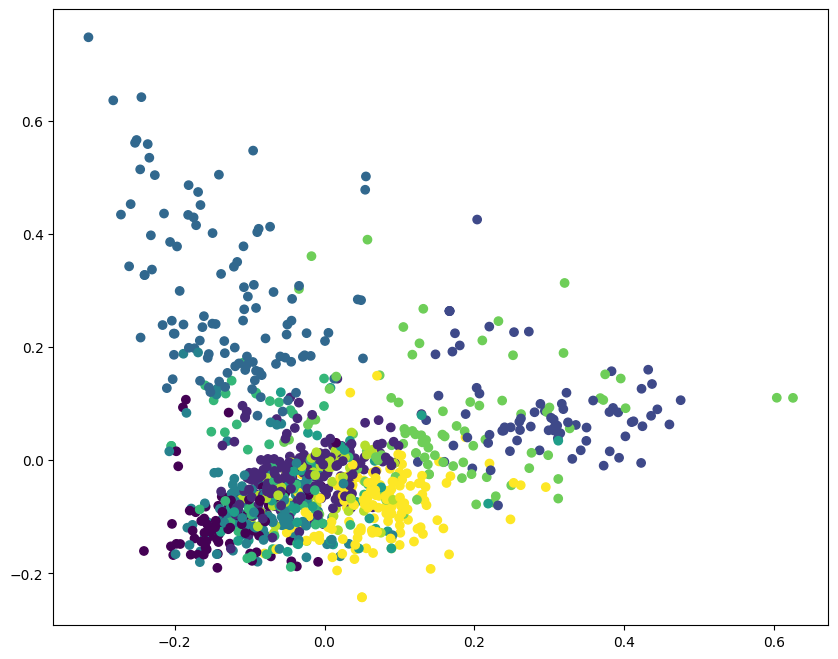

In [59]:
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster"])
plt.show()

In [61]:
import umap

C:\Users\Administrator\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


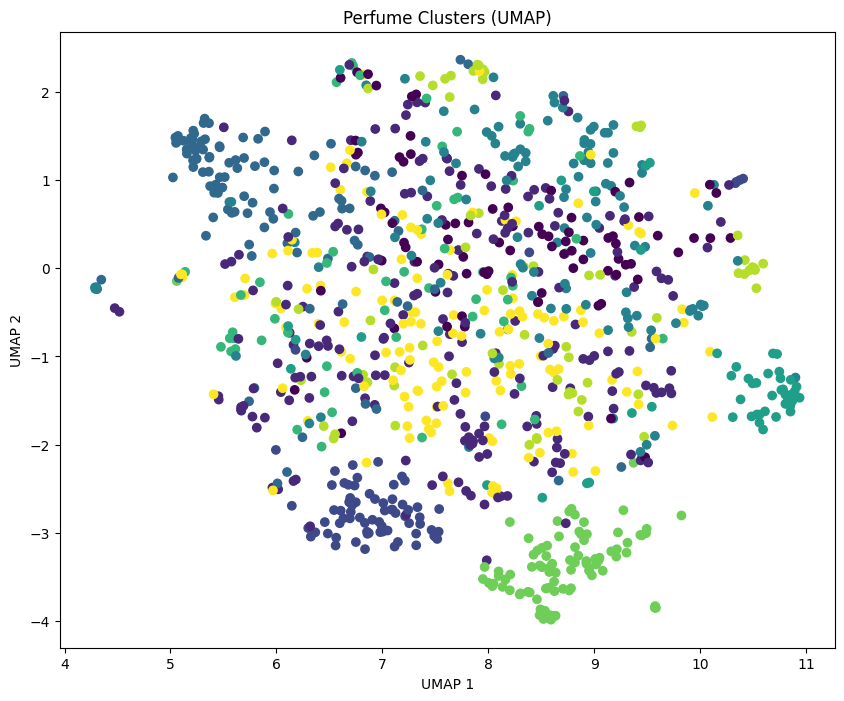

In [63]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_2d = reducer.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster"])
plt.title("Perfume Clusters (UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [64]:
import joblib

In [65]:
joblib.dump(vectorizer, "../data/tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [66]:
joblib.dump(X, "../data/tfidf_matrix.pkl")

['tfidf_matrix.pkl']

In [67]:
joblib.dump(similarity, "../data/similarity_matrix.pkl")

['similarity_matrix.pkl']

In [68]:
joblib.dump(model, "../data/kmeans_model.pkl")

['kmeans_model.pkl']

In [69]:
df.groupby("cluster")["name"].count()

cluster
0     85
1    214
2     78
3    108
4    121
5     52
6     59
7     90
8     68
9    140
Name: name, dtype: int64

In [70]:
from sklearn.cluster import HDBSCAN

In [83]:
hdb_model = HDBSCAN(min_cluster_size=10, min_samples=3, metric="cosine")

In [84]:
hdb_clusters = hdb_model.fit_predict(X.toarray())

In [85]:
df["hdbscan_cluster"] = hdb_clusters

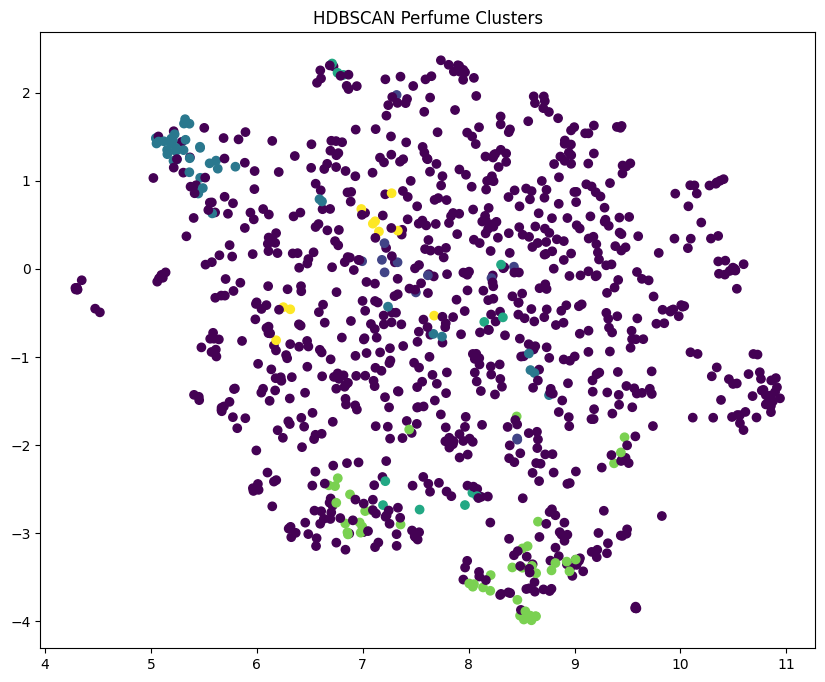

In [86]:
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["hdbscan_cluster"])
plt.title("HDBSCAN Perfume Clusters")
plt.show()